# Stochastic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network via SimPy discrete-event simulation across the full adaptation axis, and cross-check against the analytic closed-form solution.

**Inputs**:
- `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts; same source as the analytic method).
- `data/config/method/stochastic.json` (SimPy method parameters: seed, replications, horizon / warmup in invocations, ...).
- `data/reference/baseline.json` (R1 / R2 thresholds).

**Outputs**:
- `data/results/stochastic/<adaptation>/<profile>.json` - per-run metrics (nodes with `_std` columns + network aggregate + routing + `lambda_z` + embedded `method_config`).
- `data/results/stochastic/<adaptation>/requirements.json` - R1 / R2 verdicts.
- `data/img/stochastic/<adaptation>/*.{png,svg}` - topology, heatmap, diffmap, CI bars, network bars, delta figures.

**Equivalent CLI**:
```bash
python -m src.methods.stochastic --adaptation baseline
python -m src.methods.stochastic --adaptation s1
python -m src.methods.stochastic --adaptation s2
python -m src.methods.stochastic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.stochastic` and `src.view.qn_diagram`. The cells below orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run as run_analytic
from src.methods.stochastic import run as run_stochastic
from src.view import (
    plot_qn_topology,
    plot_node_heatmap,
    plot_node_diffmap,
    plot_node_ci,
    plot_arch_bars,
    plot_arch_delta,
)

IMG_ROOT = Path("data/img/stochastic")
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

## 1. Solve every adaptation (SimPy DES)

`run_stochastic(adp=a, wrt=True)` loads `NetCfg`, pulls the method config (seed / replications / horizon / warmup), runs the DES engine across every replication, writes the JSON envelope, and returns the per-replication-averaged per-node frame + network aggregate + R1 / R2 verdict.

In [2]:
results = {
    a: run_stochastic(adp=a, wrt=True) for a in ADAPTATIONS
}

In [3]:
cfgs = {a: results[a]["config"] for a in ADAPTATIONS}
nodes = {a: results[a]["nodes"] for a in ADAPTATIONS}
nets = {a: results[a]["network"] for a in ADAPTATIONS}
reqs = {a: results[a]["requirements"] for a in ADAPTATIONS}
mc = results["baseline"]["method_config"]

In [4]:
# analytic baseline cached once for the CI overlay reference in section 6
analytic_baseline_nodes = run_analytic(adp="baseline",
                                       wrt=False)["nodes"]

print(f"Solved {len(results)} adaptations via SimPy DES; "
      f"seed={mc['seed']} reps={mc['replications']} "
      f"horizon={mc['horizon_invocations']} inv. "
      f"warmup={mc['warmup_invocations']} inv.")

Solved 4 adaptations via SimPy DES; seed=42 reps=10 horizon=10000 inv. warmup=1000 inv.


## 2. Network-wide summary + verdict

One row per adaptation: mean headline metrics across replications and the R1 / R2 pass flags.

In [5]:
rows = []
for a in ADAPTATIONS:
    n = nets[a].iloc[0]
    r = reqs[a]
    rows.append({
        "adaptation": a,
        "profile": cfgs[a].profile,
        r"$\mathbf{\overline{W}_{TAS}}$ [ms]": n["W_net"] * 1000,
        r"$\mathbf{\overline{\rho}_{TAS}}$": n["avg_rho"],
        r"$\mathbf{\rho_{TAS,\,Max}}$": n["max_rho"],
        r"$\mathbf{\overline{L}_{TAS}}$": n["L_net"],
        "R1": "PASS" if r["R1"]["pass"] else "FAIL",
        "R2": "PASS" if r["R2"]["pass"] else "FAIL",
    })
pd.DataFrame(rows).set_index("adaptation").round(4)

,profile,$\mathbf{\overline{W}_{TAS}}$ [ms],$\mathbf{\overline{\rho}_{TAS}}$,"$\mathbf{\rho_{TAS,\,Max}}$",$\mathbf{\overline{L}_{TAS}}$,R1,R2
adaptation,,,,,,,
baseline,dflt,3.6220,0.3045,0.6884,7.3618,PASS,PASS
s1,opti,3.2125,0.2942,0.6468,6.5140,PASS,PASS
s2,opti,3.7388,0.3136,0.7087,7.6430,PASS,PASS
aggregate,opti,3.8415,0.3113,0.6839,7.7799,PASS,PASS


## 3. Per-node snapshot (baseline, mean across reps)

Mean per-node metrics after the warm-up cut-off. The `_std` companions carry the replication-to-replication spread; the CI overlay in section 6 uses them.

In [6]:
nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "rho_std", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,rho_std,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,344.5553,698.0227,1,10,0.4937,0.0081,0.9686,0.0028
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,258.6618,702.8614,1,10,0.3681,0.0062,0.5889,0.0023
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,172.0208,703.9840,1,10,0.2444,0.0029,0.3230,0.0019
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,96.7150,179.9672,1,10,0.5376,0.0154,1.1725,0.0121
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,91.7738,532.0287,1,10,0.1726,0.0045,0.2092,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,103.5000,150.3811,1,10,0.6884,0.0164,2.0845,0.0201
6,AS_{1},Alarm Service 1,M/M/s/K,64.0473,704.0763,1,10,0.0910,0.0029,0.1002,0.0016
7,AS_{2},Alarm Service 2,M/M/s/K,59.4665,408.4275,1,10,0.1457,0.0050,0.1707,0.0029
8,AS_{3},Alarm Service 3,M/M/s/K,68.5247,1606.8677,1,10,0.0427,0.0016,0.0445,0.0006
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,255.2425,699.2417,1,10,0.3651,0.0057,0.5734,0.0022


## 4. Queue-network topology per adaptation

Nodes coloured by rho (cool = low, warm = high), scaled to the frame's max. Same plotter as the analytic notebook so the two methods compare visually.

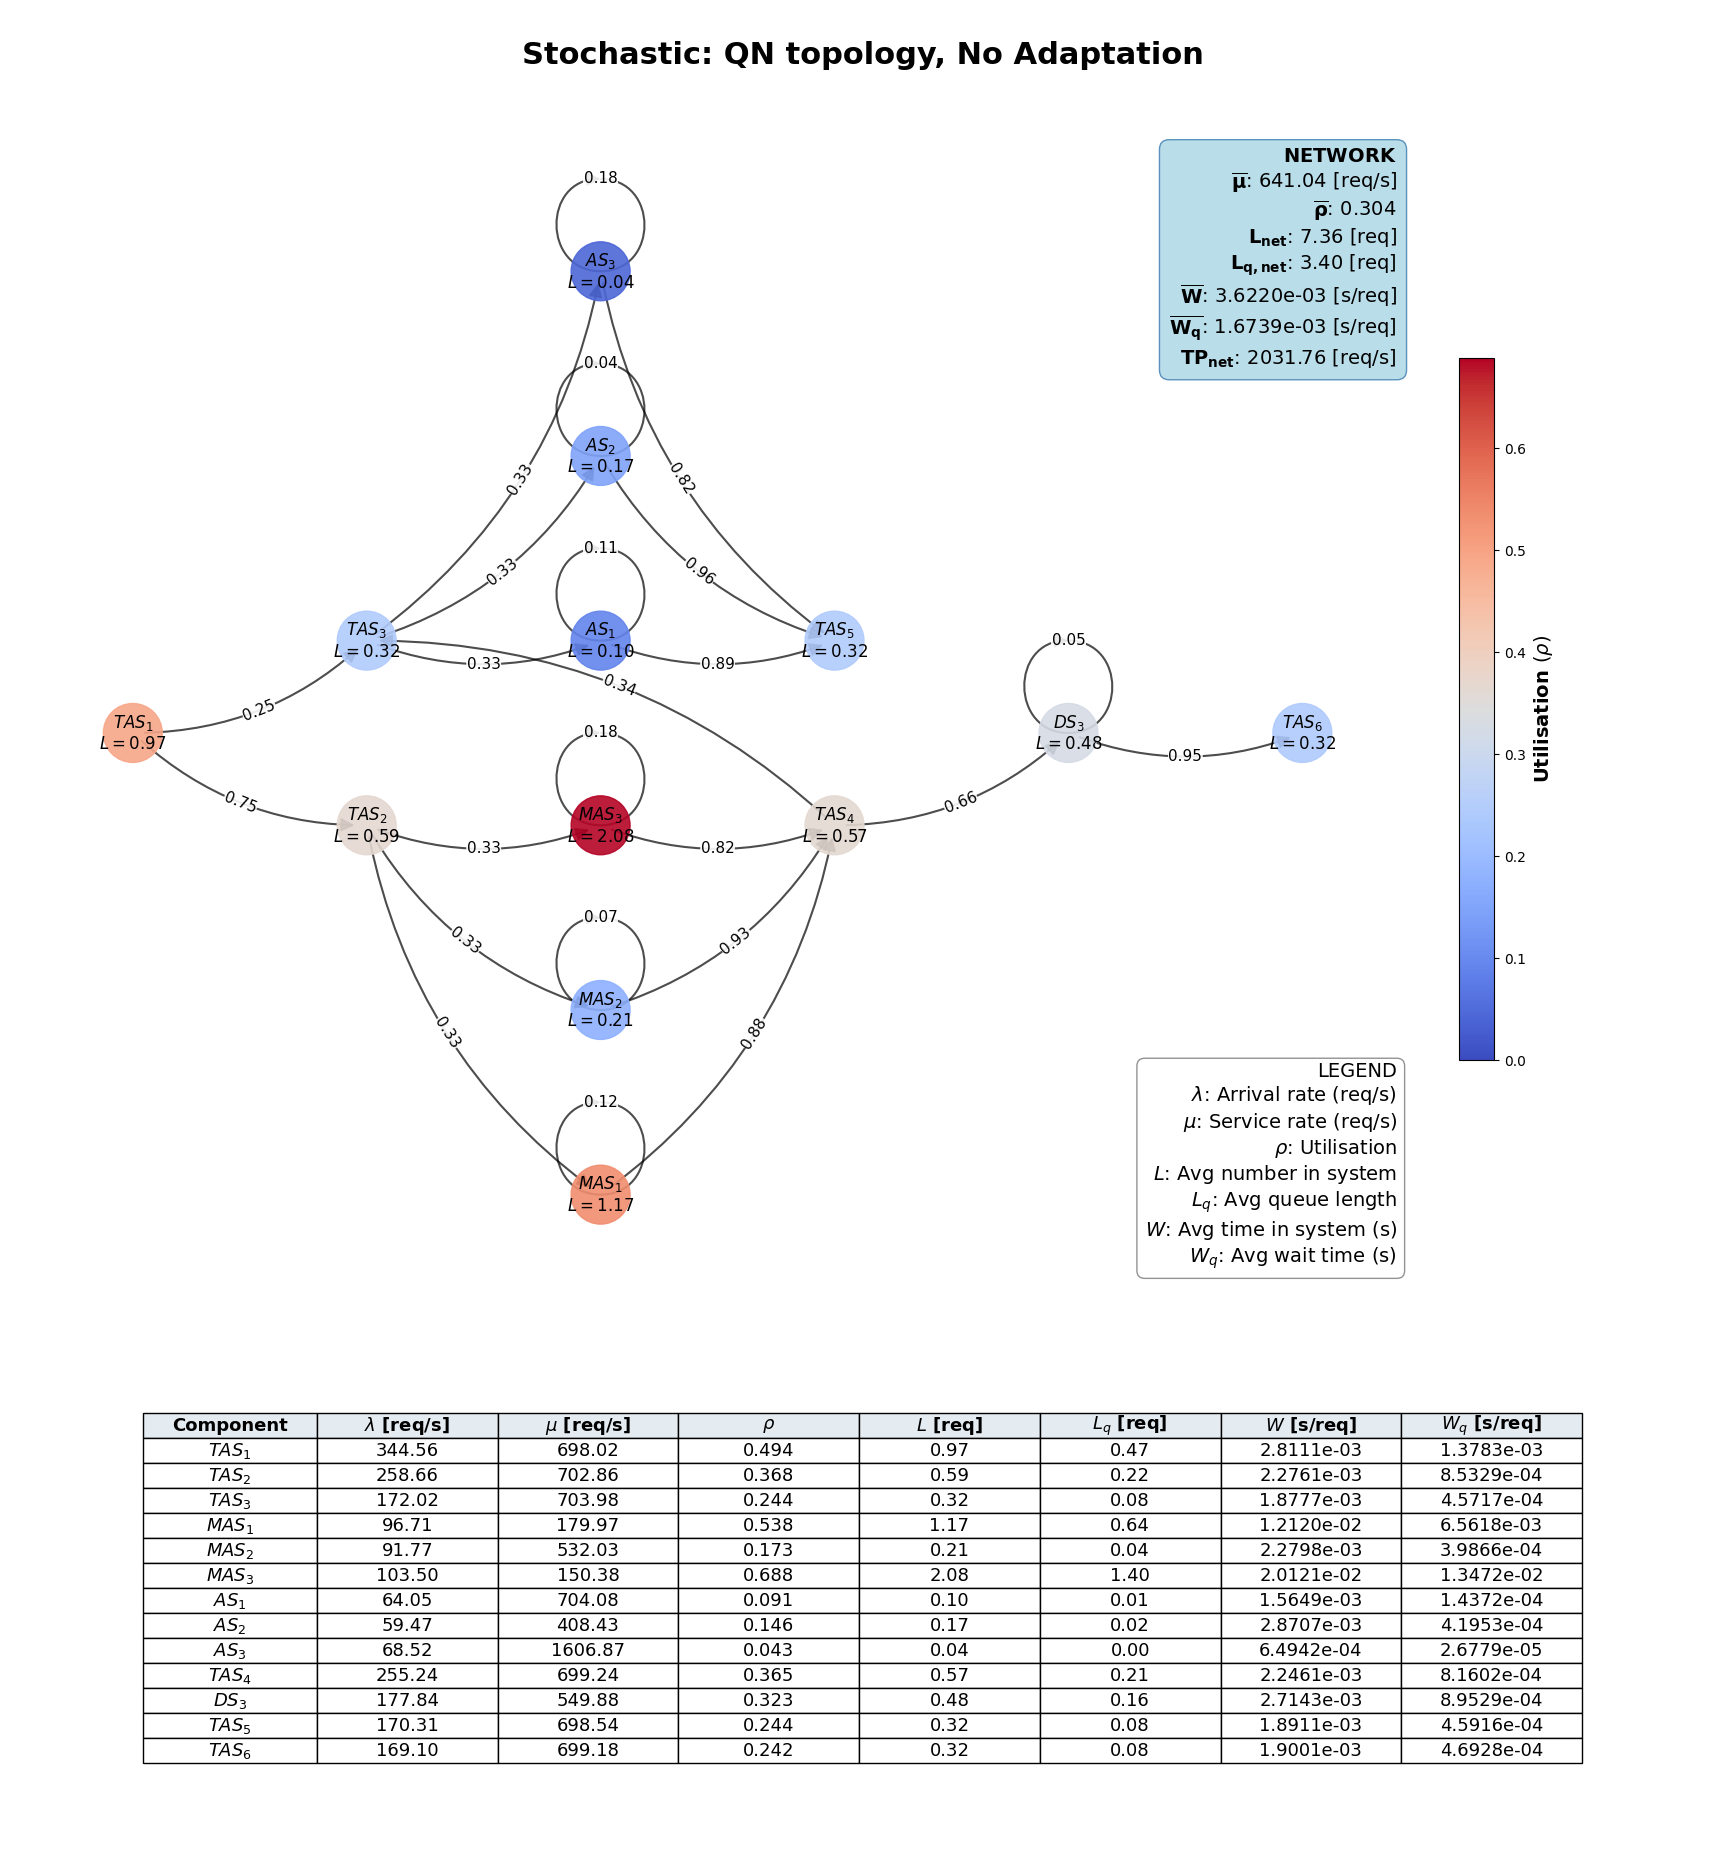

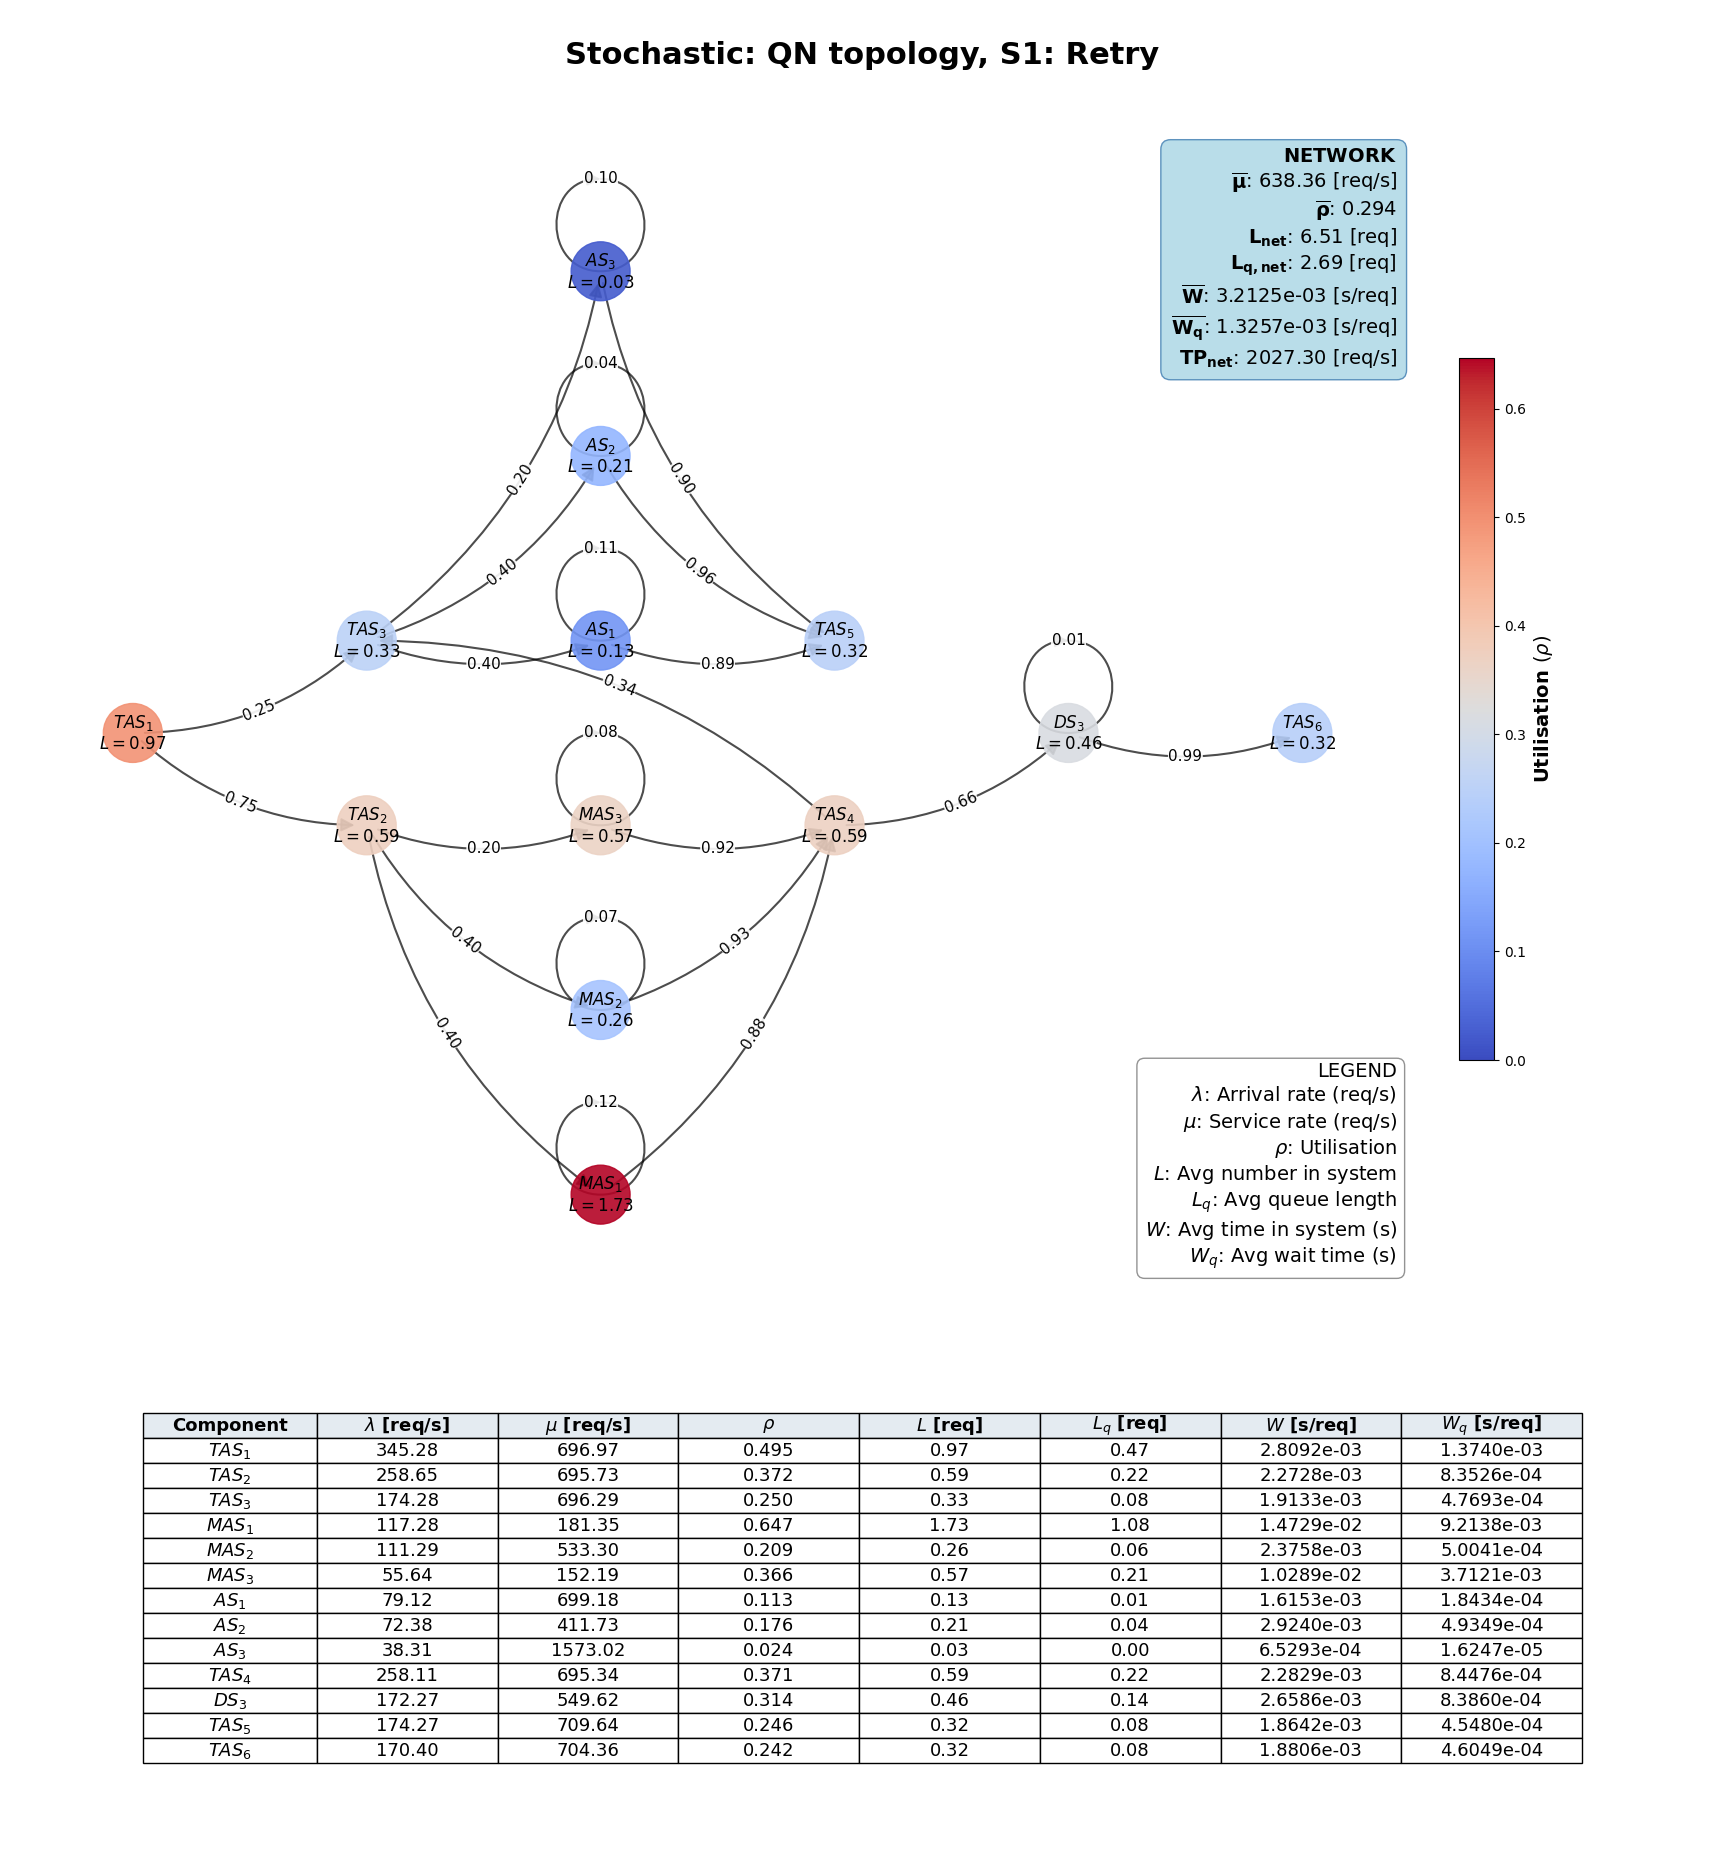

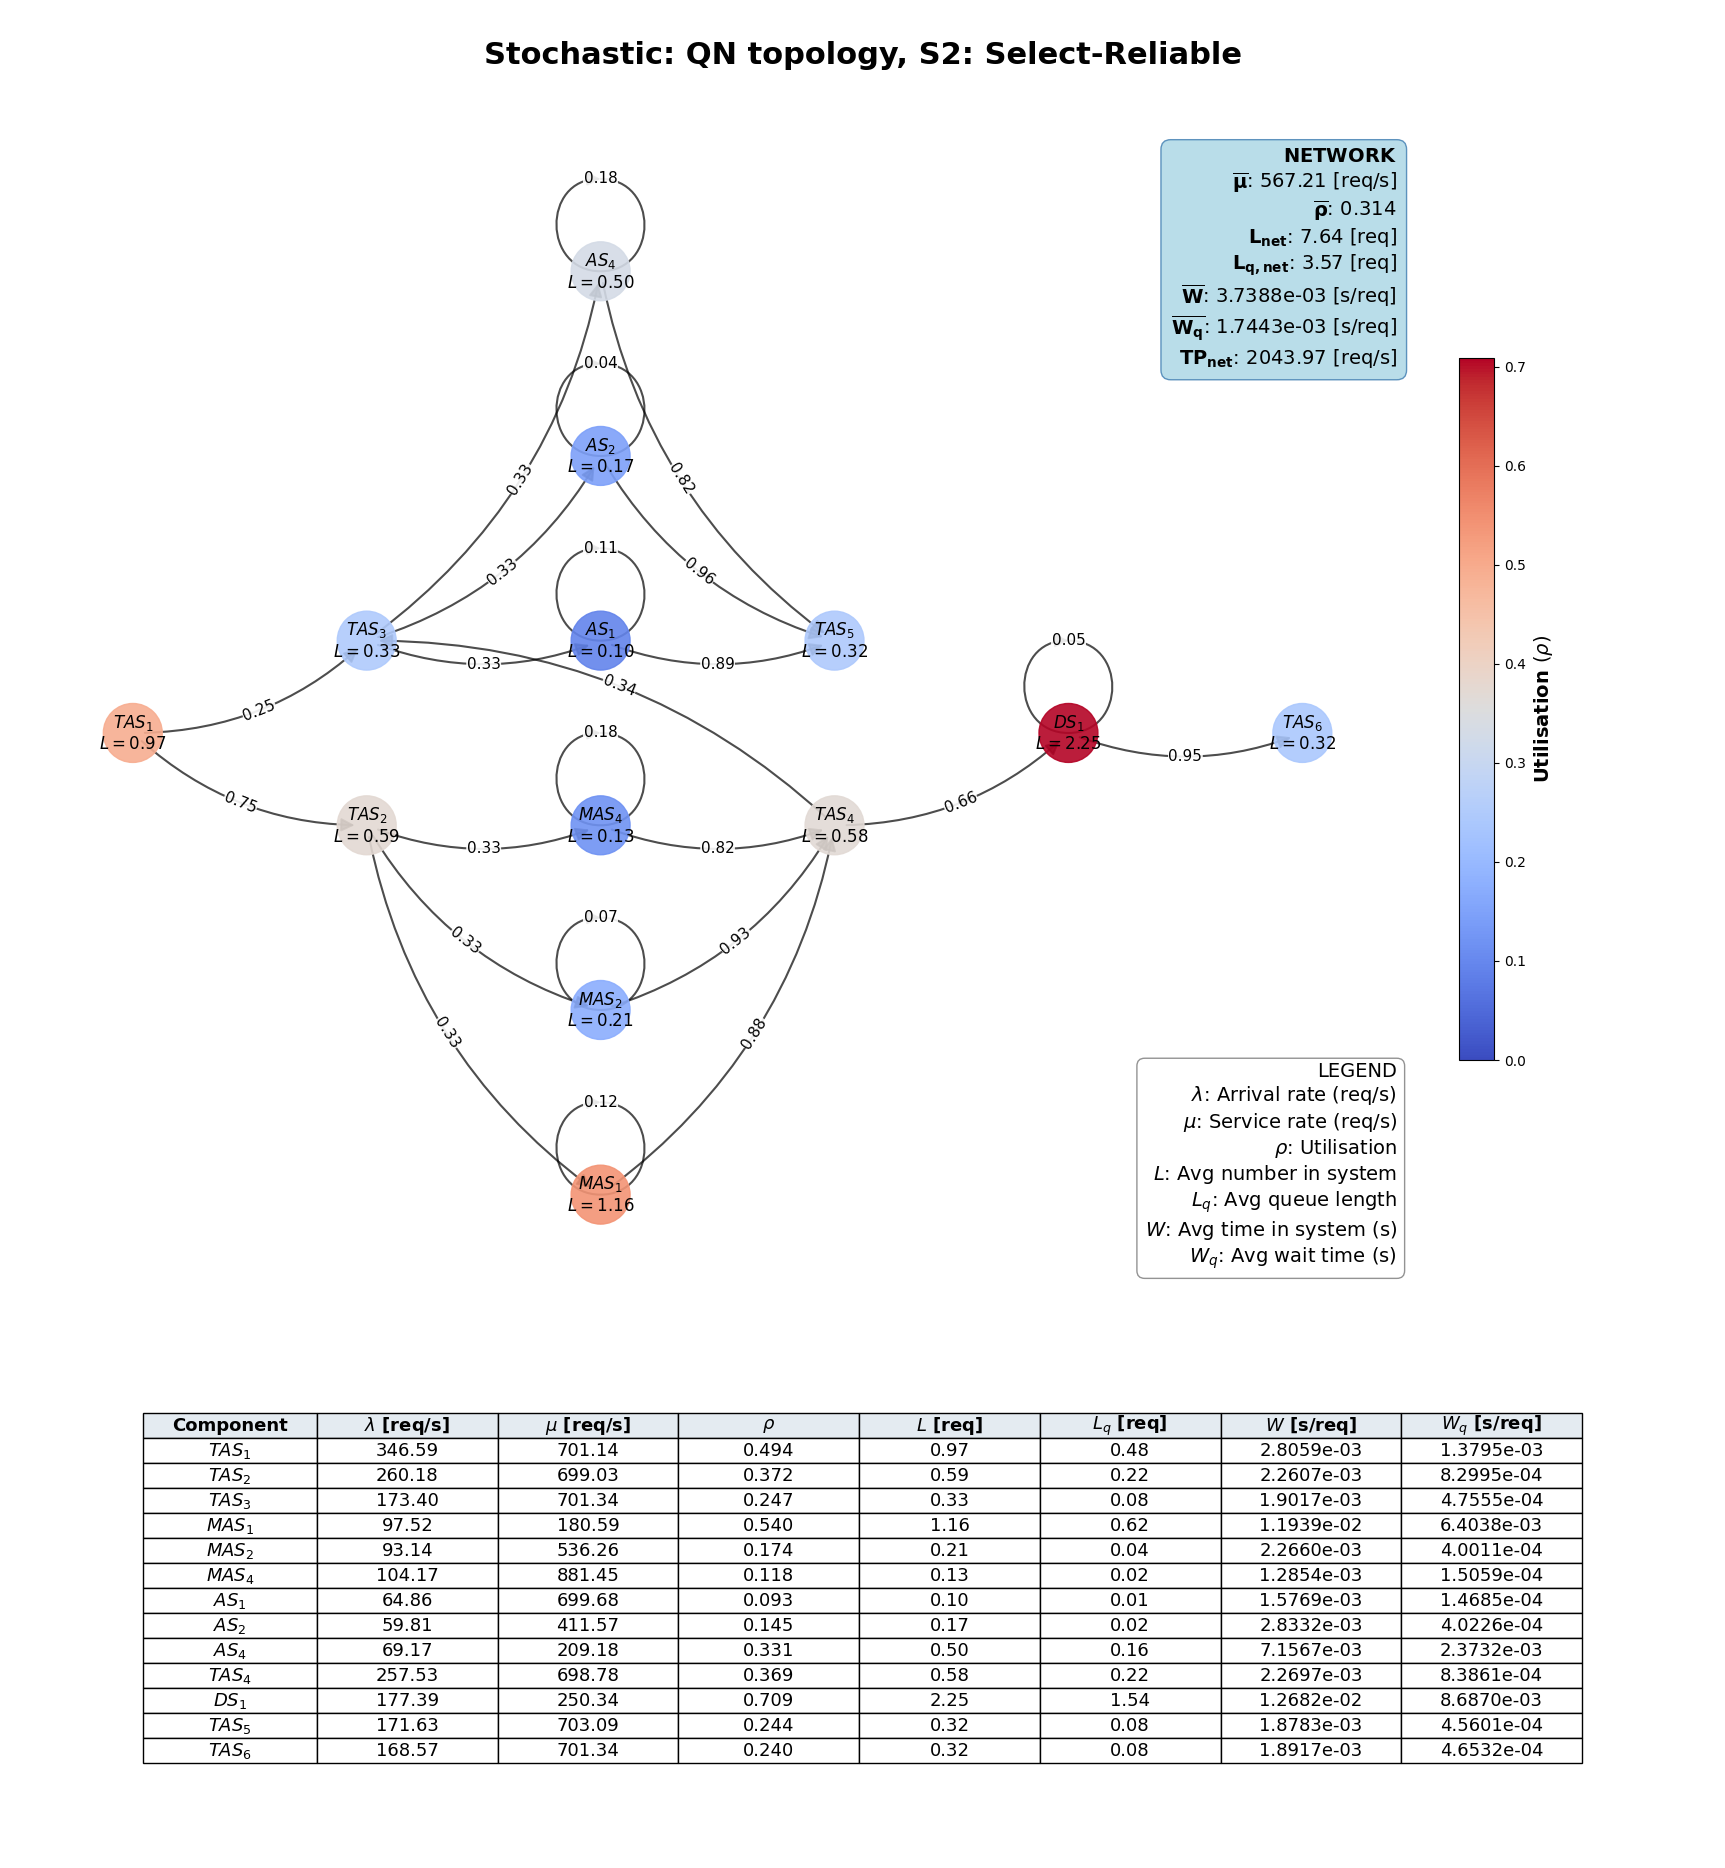

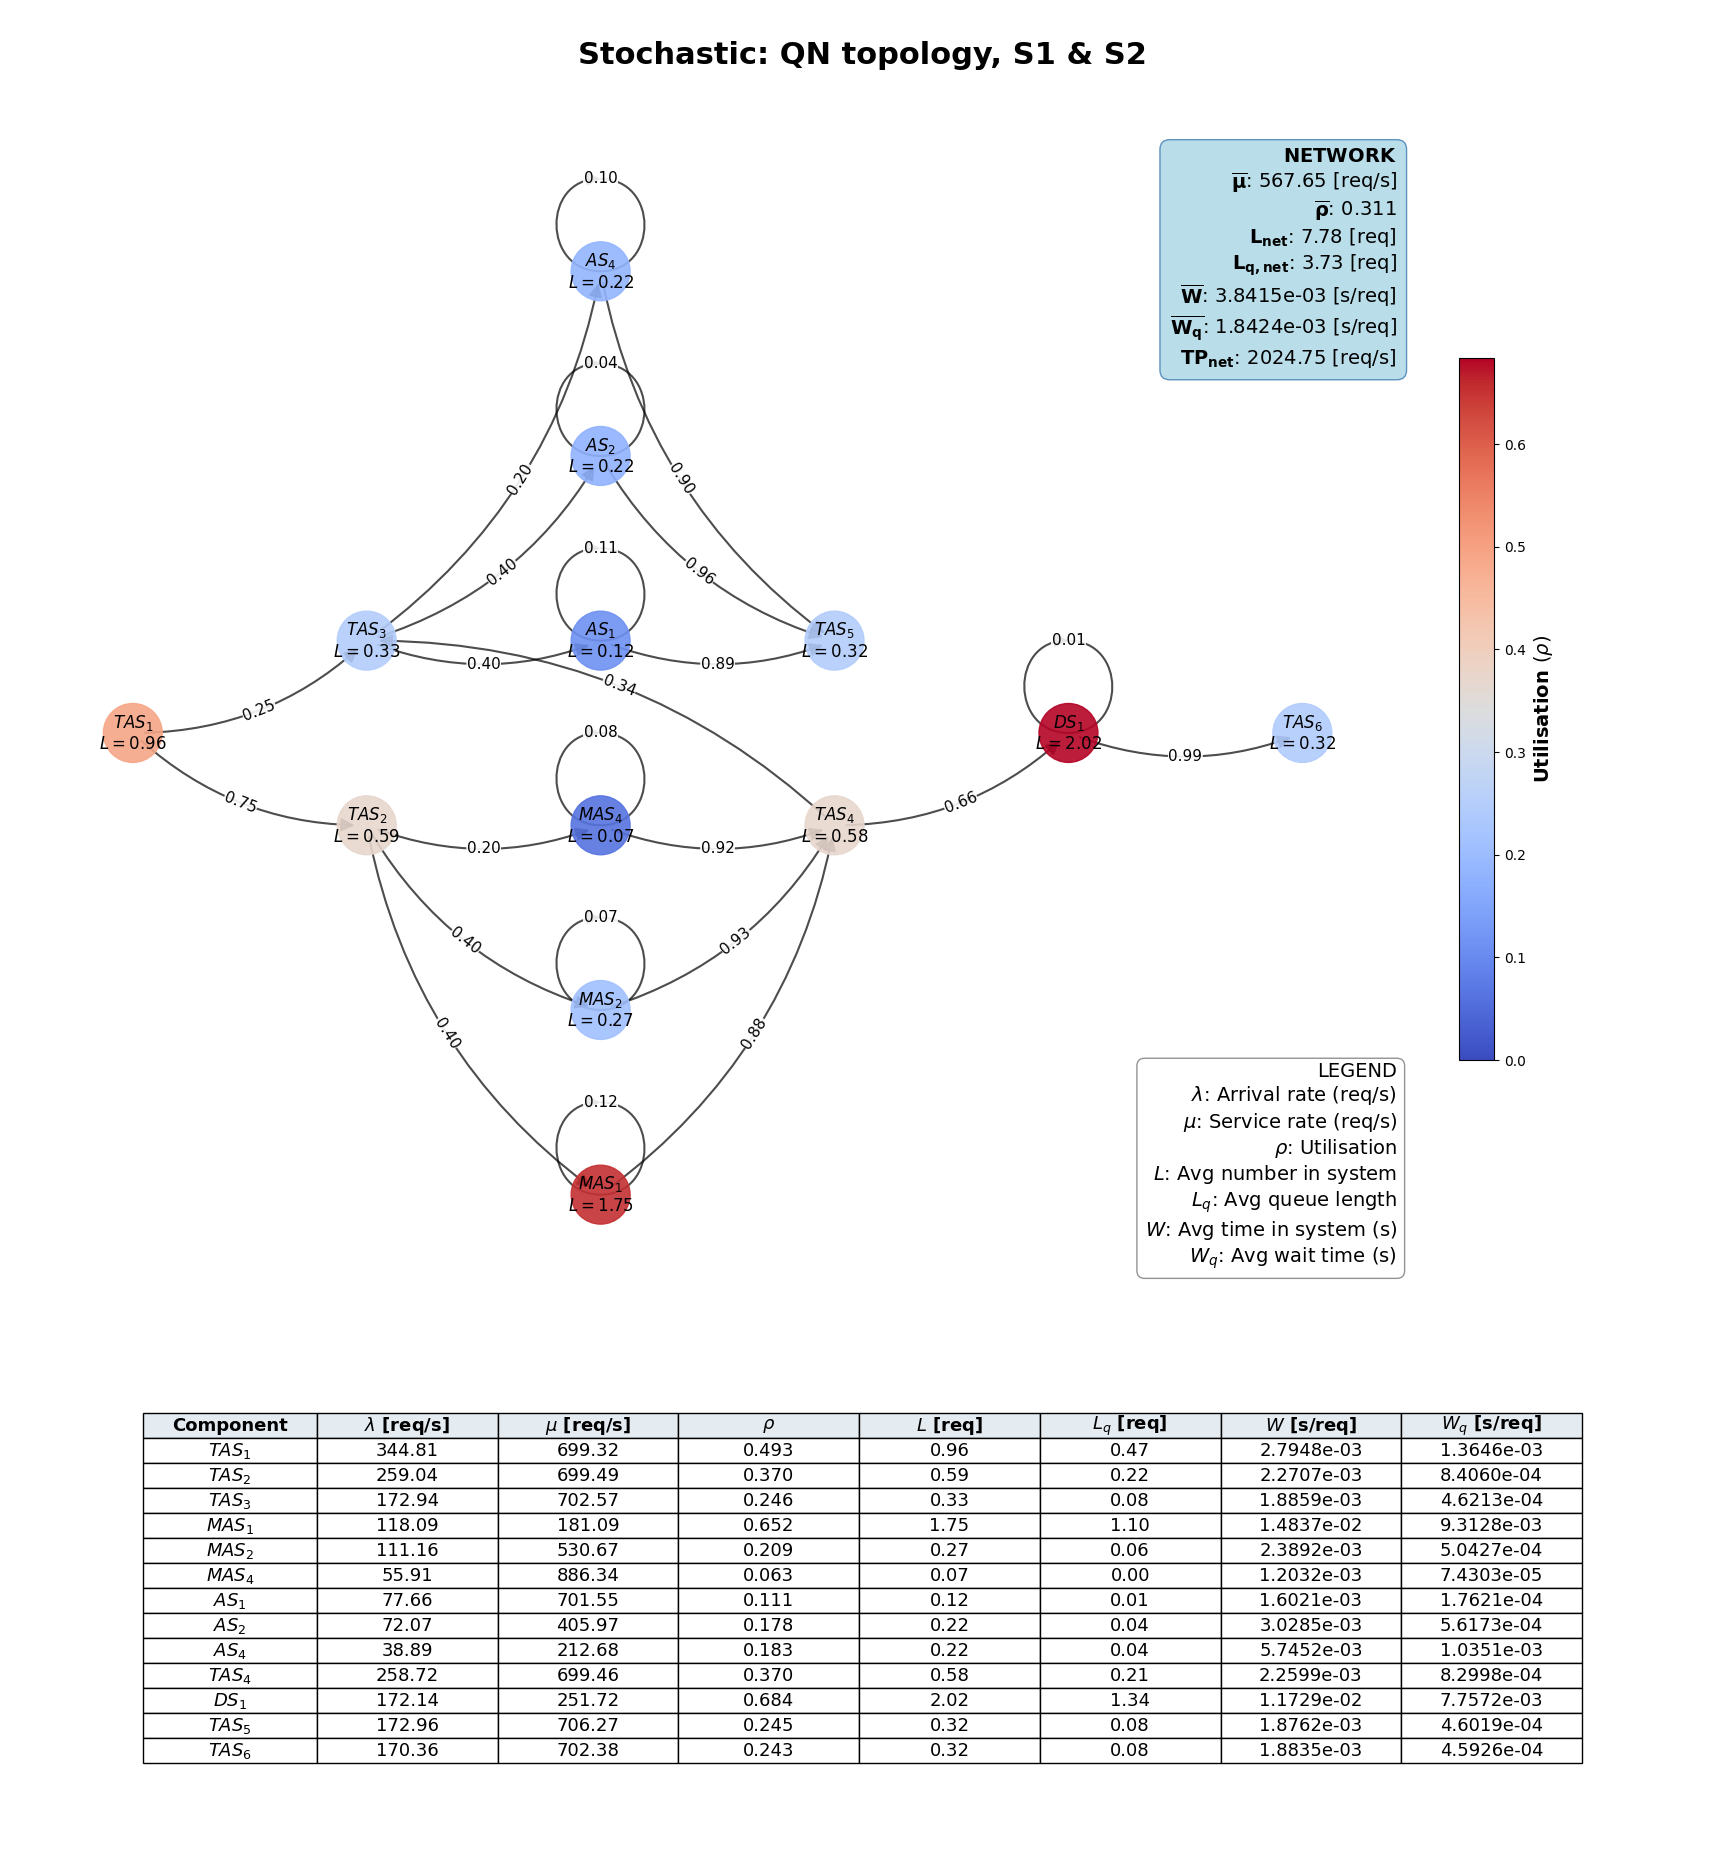

In [7]:
for a in ADAPTATIONS:
    plot_qn_topology(
        routs=cfgs[a].routing,
        ndss=nodes[a],
        nets=nets[a],
        title=f"Stochastic: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns normalised per-metric across both scenarios.

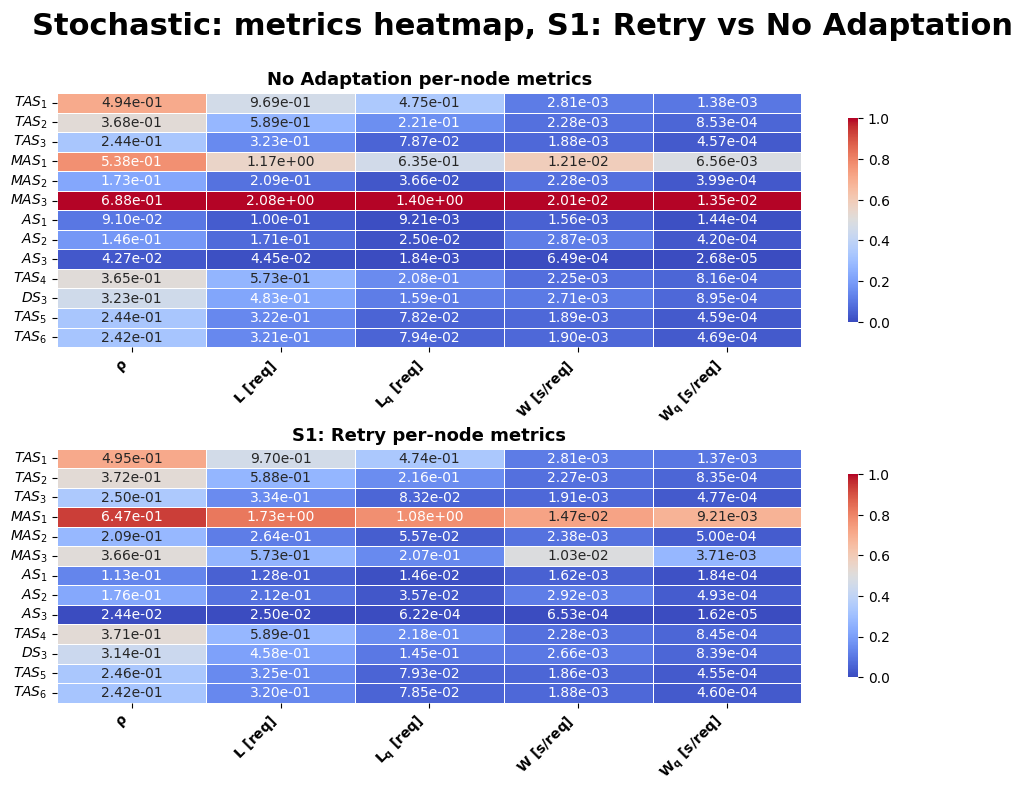

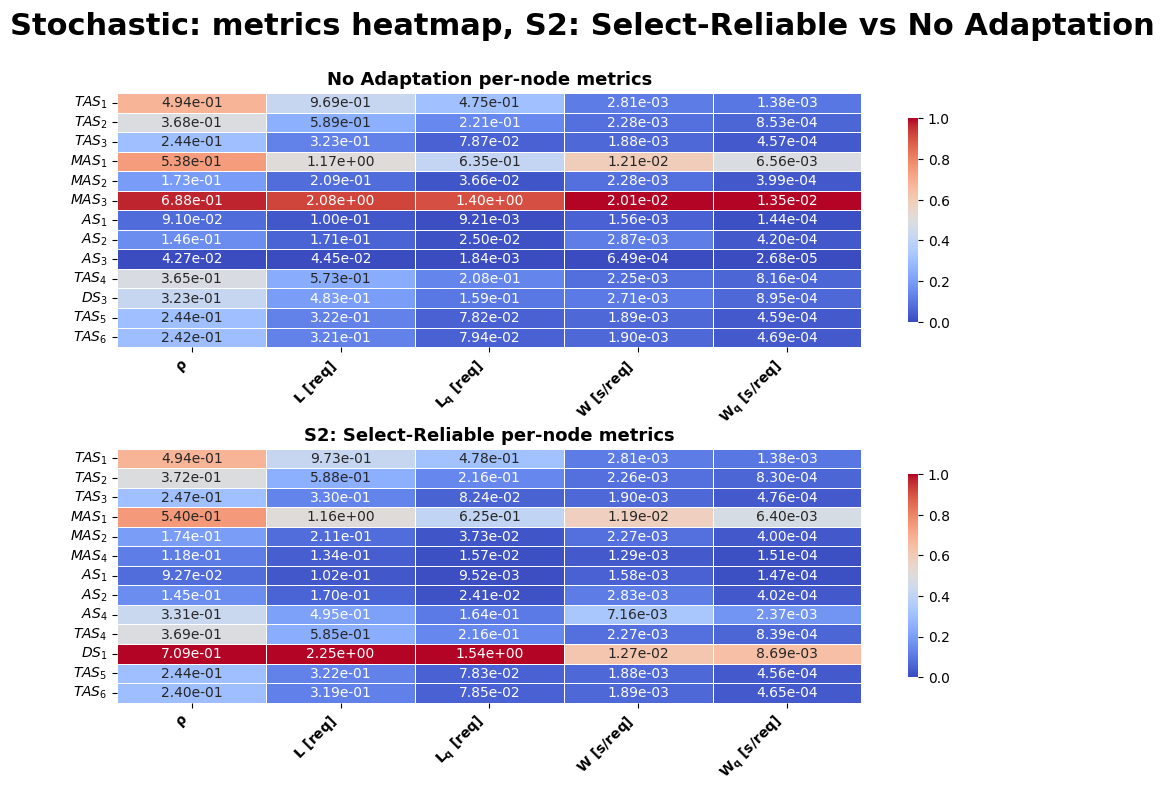

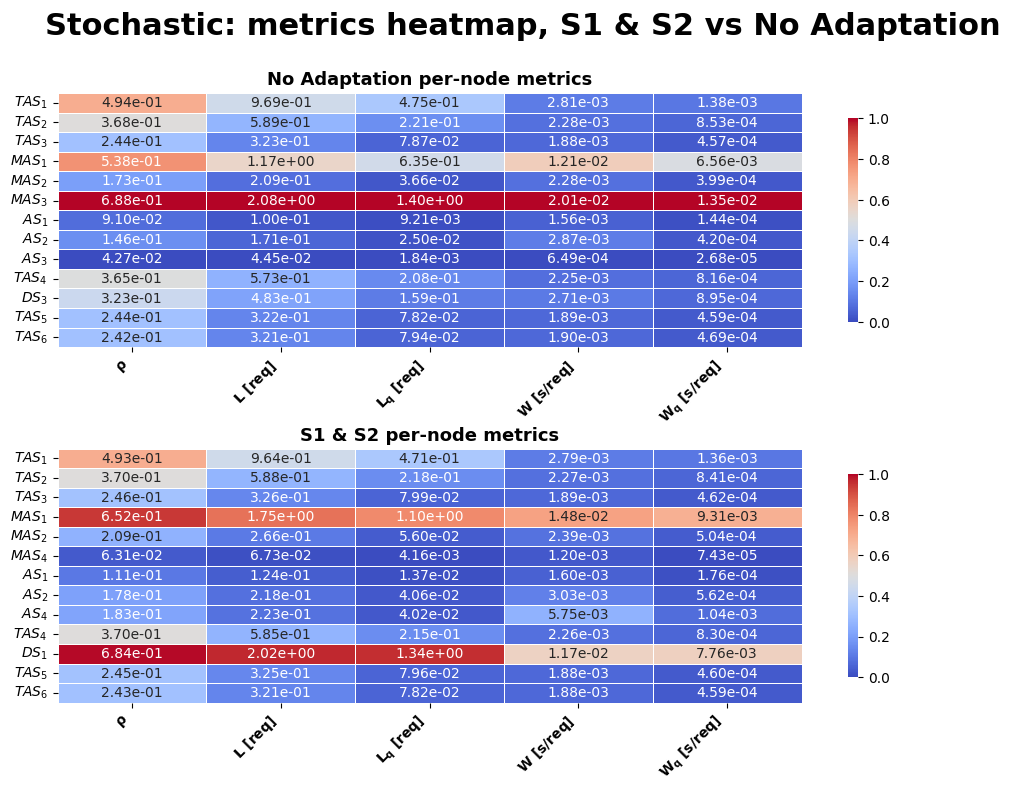

In [8]:
heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
heat_labels = [
    r"$\mathbf{\rho}$",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s/req]",
    r"$\mathbf{W_q}$ [s/req]",
]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3}/DS_{3} and s2/aggregate's MAS_{4}/AS_{4}/DS_{1} at the same row position.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Stochastic: metrics heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (ratio vs baseline)

Same `(opti - dflt) / |dflt|` ratio convention as the analytic method (matches `__OLD__/src/exports/analytical_draft.py`). Values render as fractions: 35.82 reads as 3582 %.

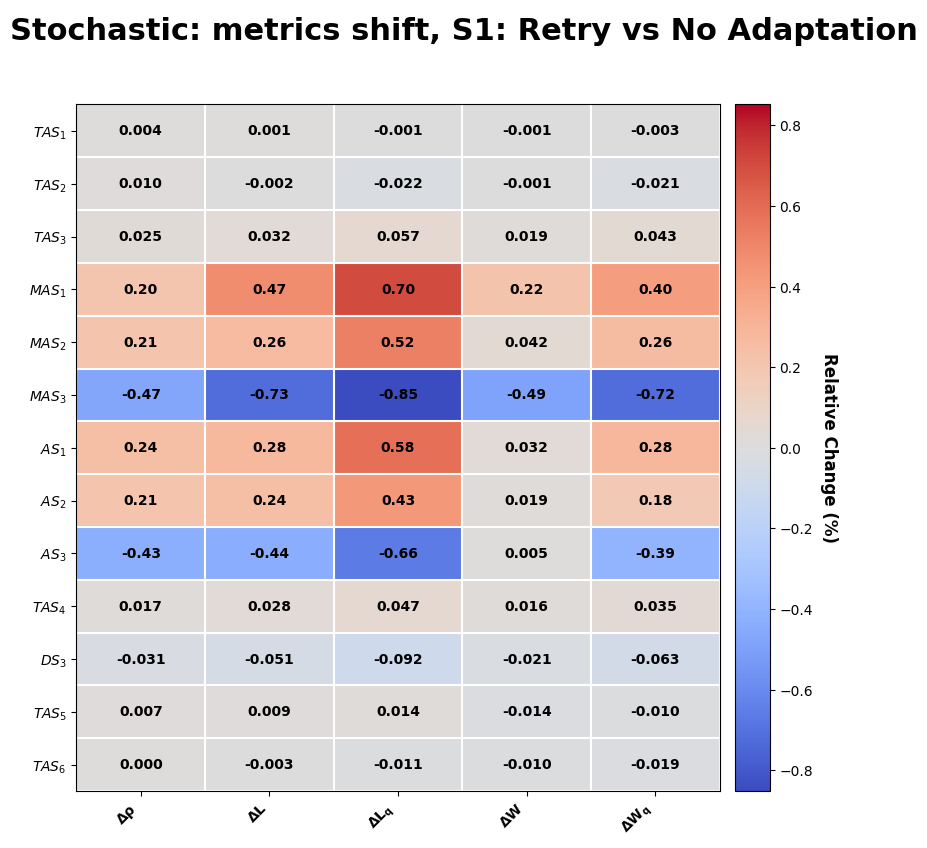

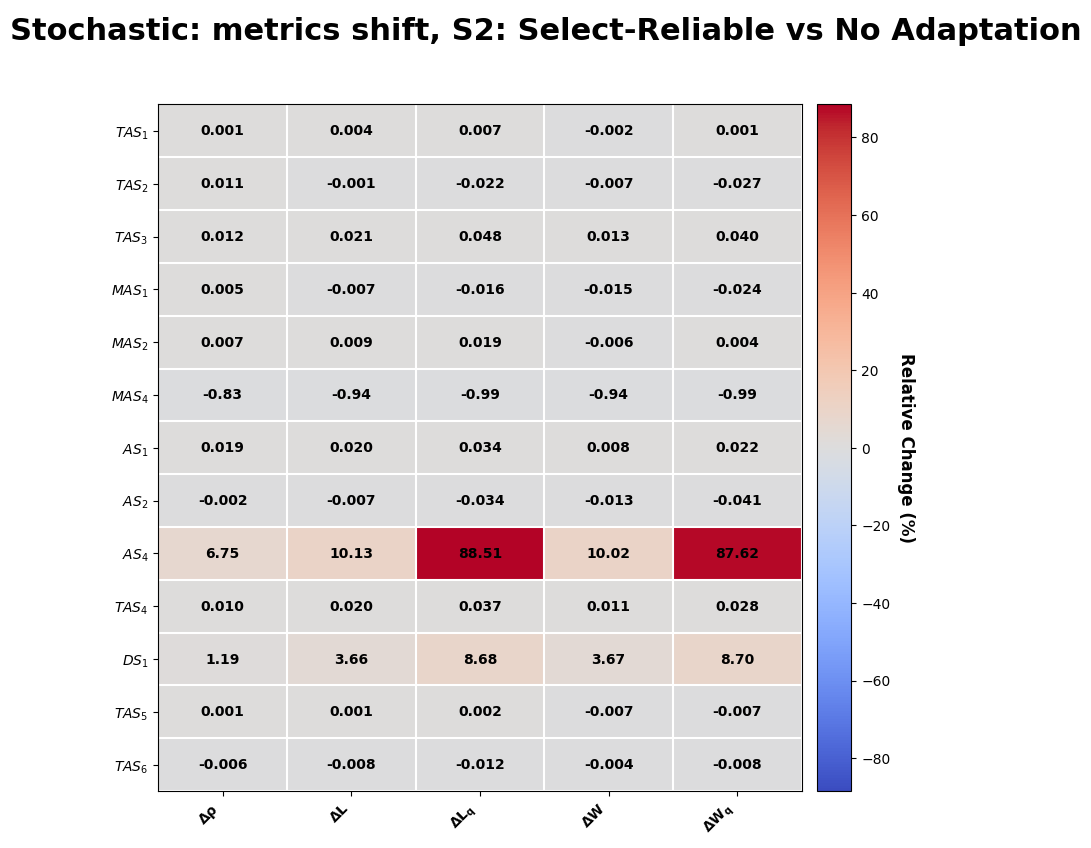

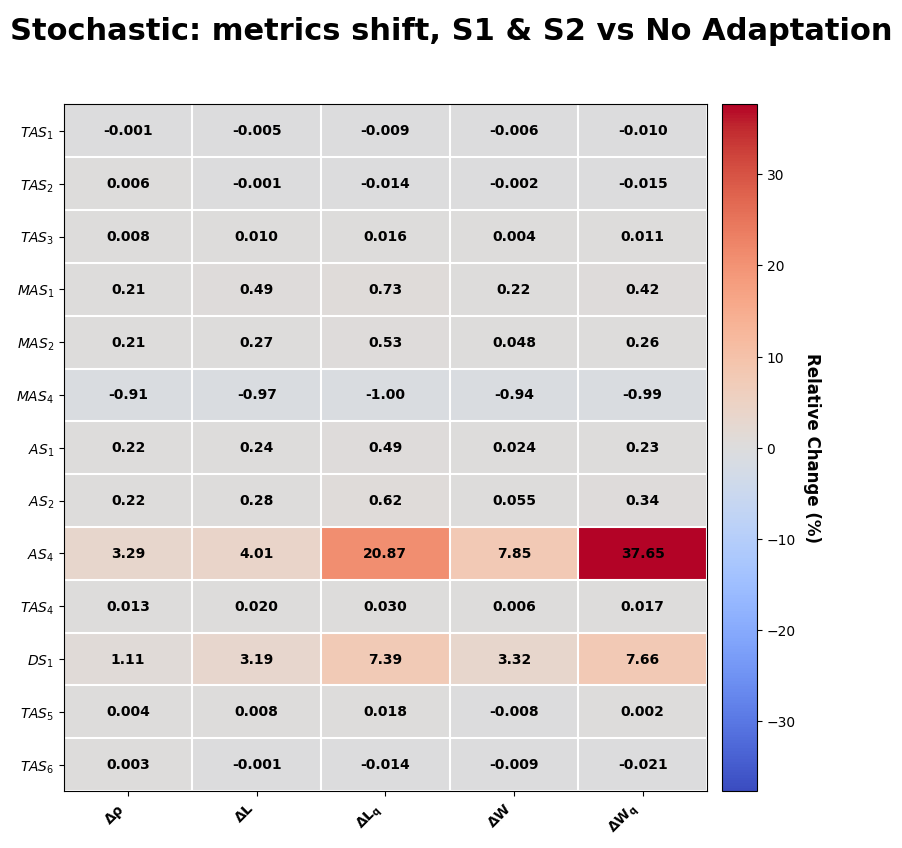

In [9]:
diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
diff_labels = [
    r"$\mathbf{\Delta \rho}$",
    r"$\mathbf{\Delta L}$",
    r"$\mathbf{\Delta L_q}$",
    r"$\mathbf{\Delta W}$",
    r"$\mathbf{\Delta W_q}$",
]
# Align by positional row index (baseline MAS_{3} vs s2 MAS_{4} at the same row);
# y-axis carries each adp's actual service keys.
bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in diff_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)
    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=diff_metrics,
        labels=diff_labels,
        title=f"Stochastic: metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Per-node confidence-interval bands (stochastic-only)

For each adaptation, plot the per-node mean with a 95 % CI error bar (half-width = `z * sigma / sqrt(reps)` using the replication-level sigma from the `_std` columns). The analytic closed-form baseline is overlaid as red `x` markers so the two methods can be eyeballed against each other: the analytic value should fall INSIDE the stochastic CI when the engine is calibrated correctly.

Both `rho` and `W` get their own panels per adaptation.

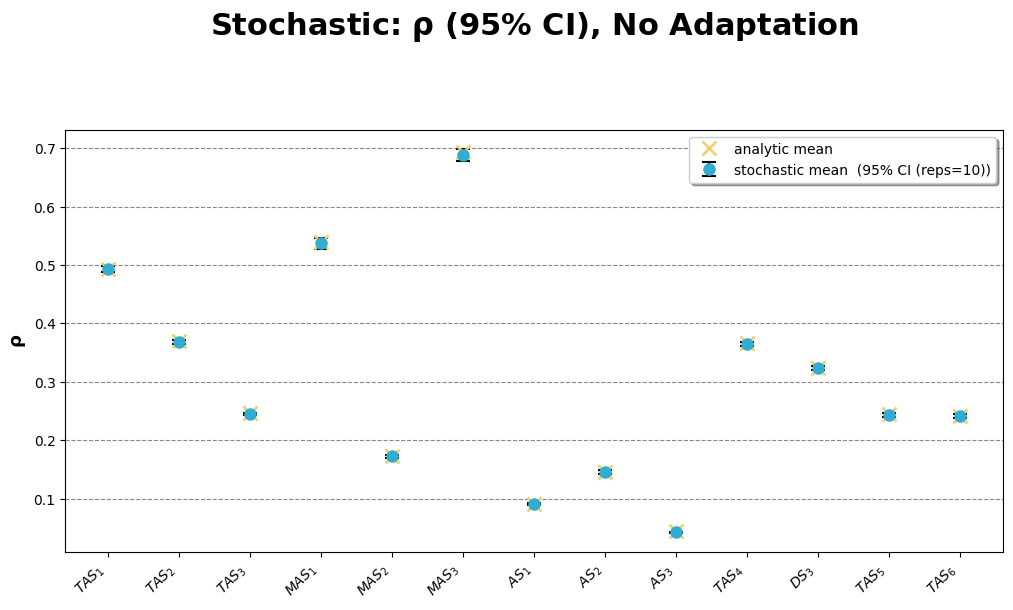

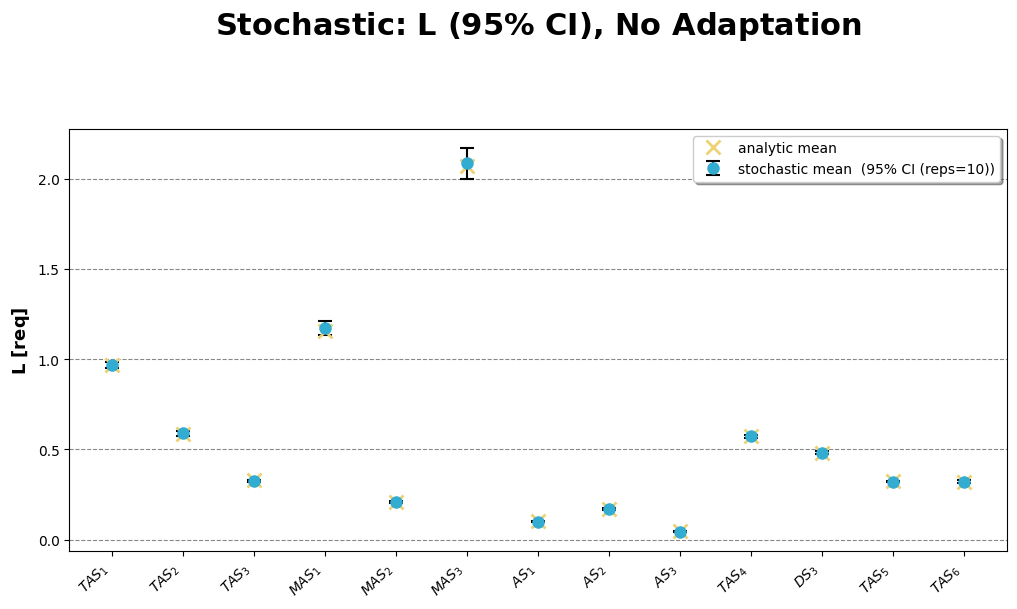

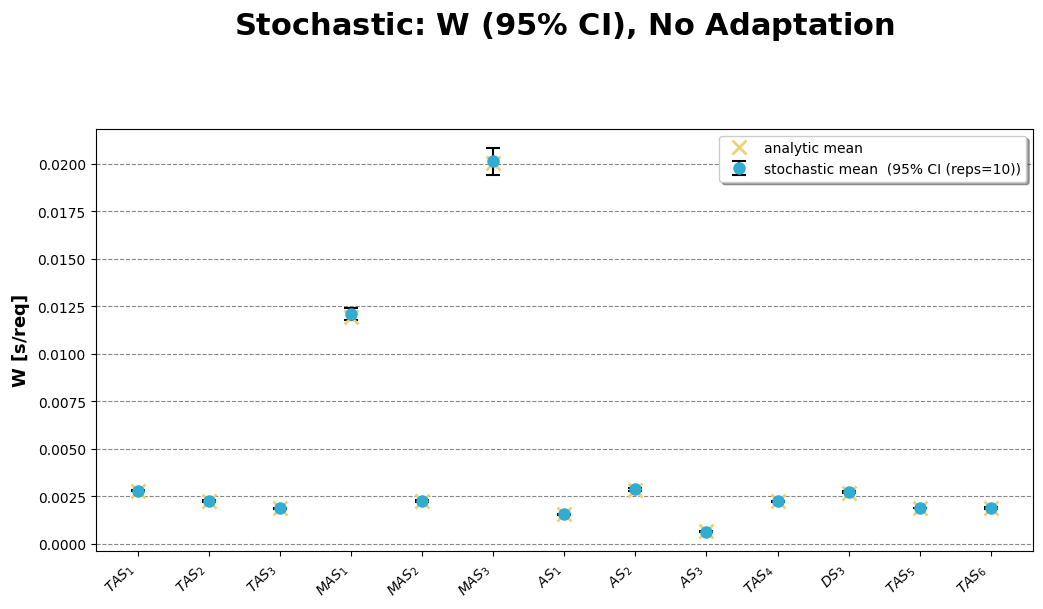

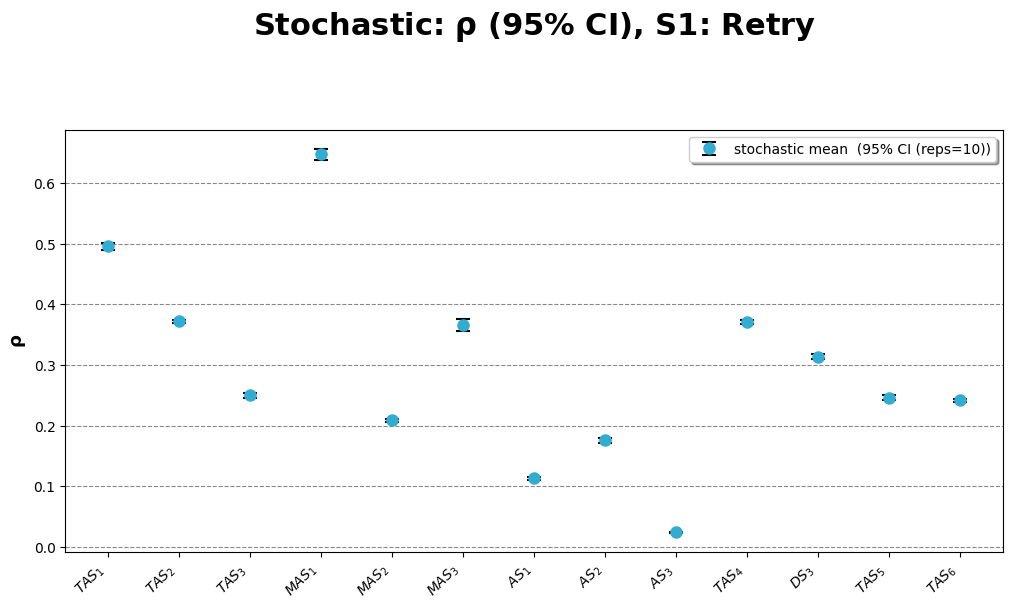

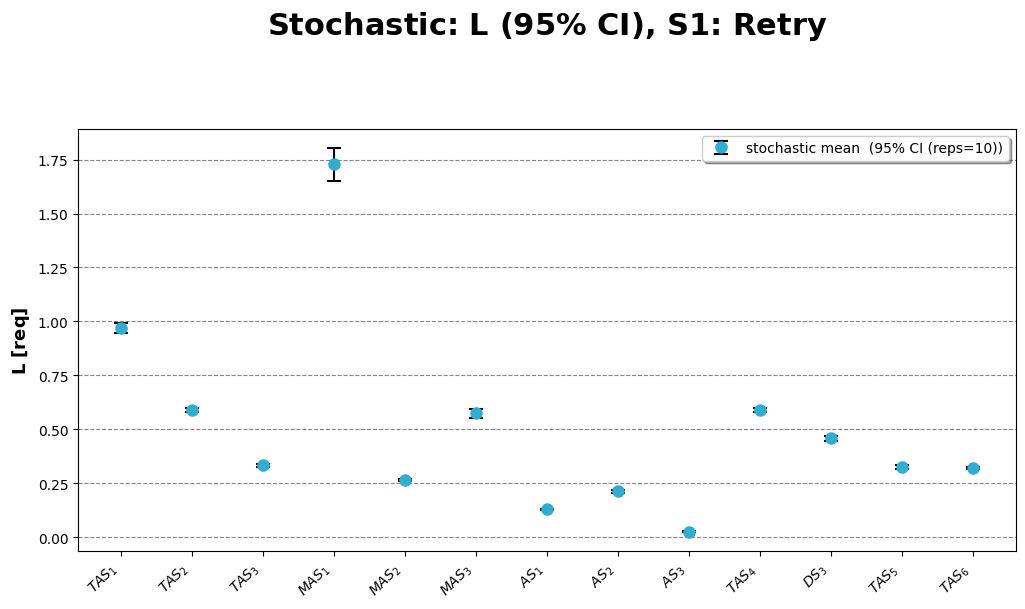

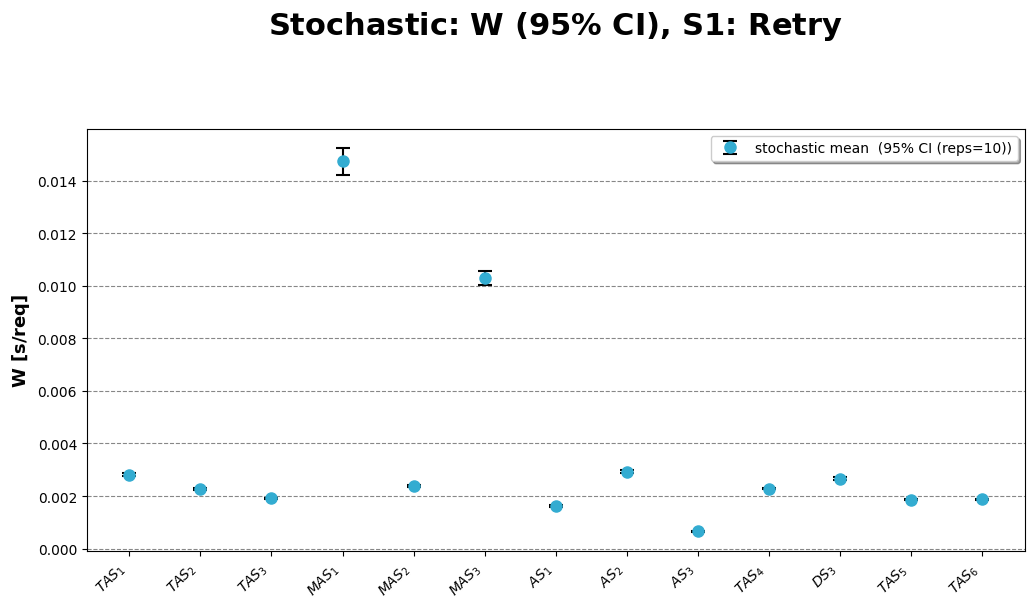

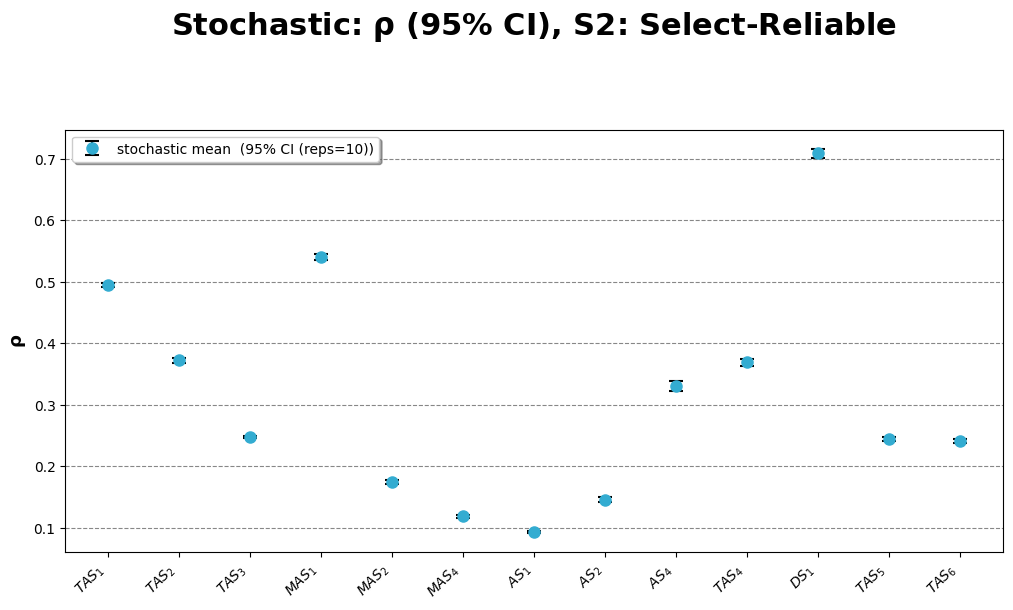

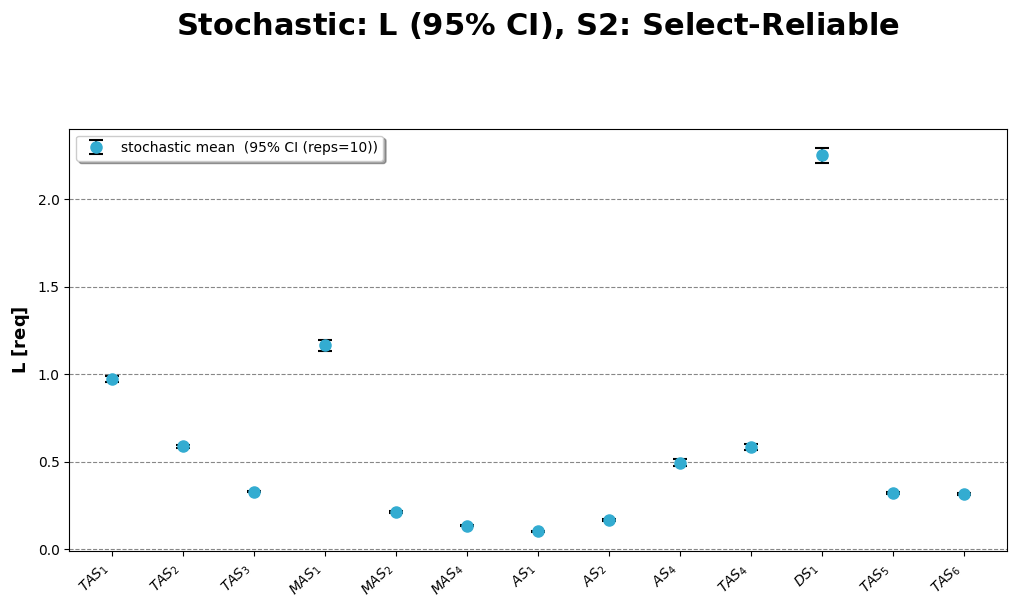

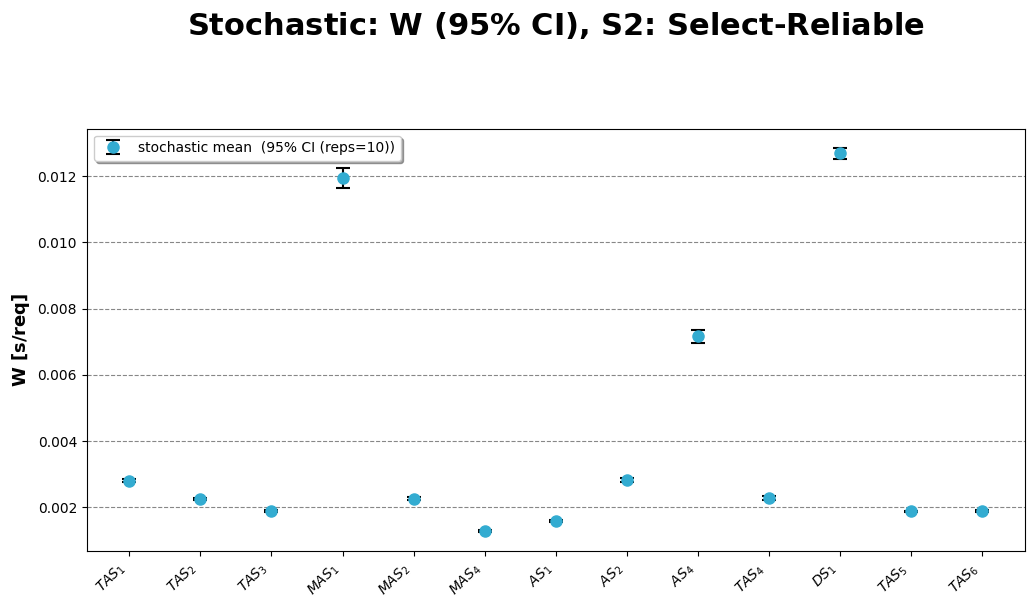

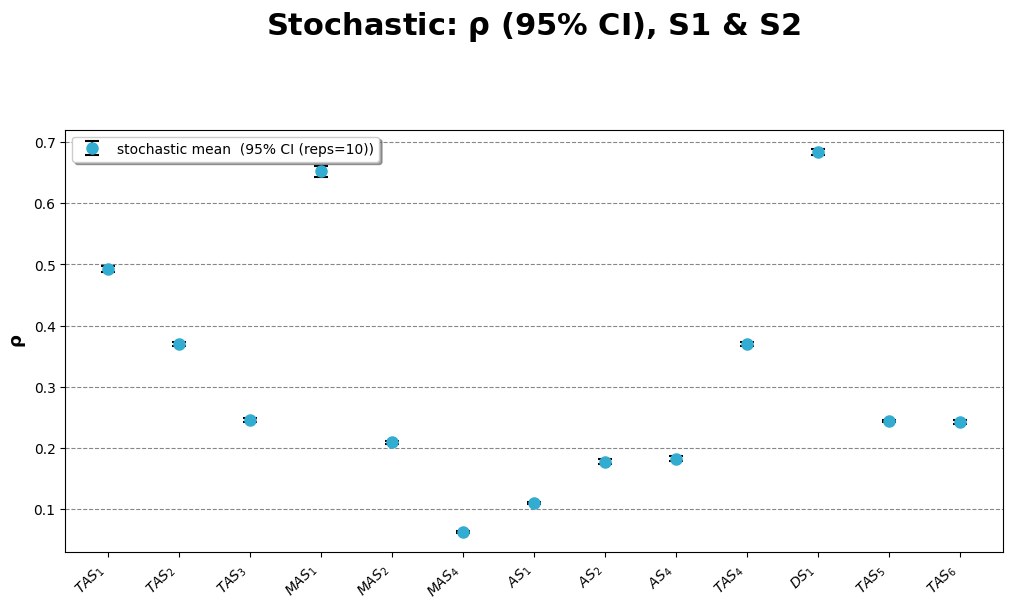

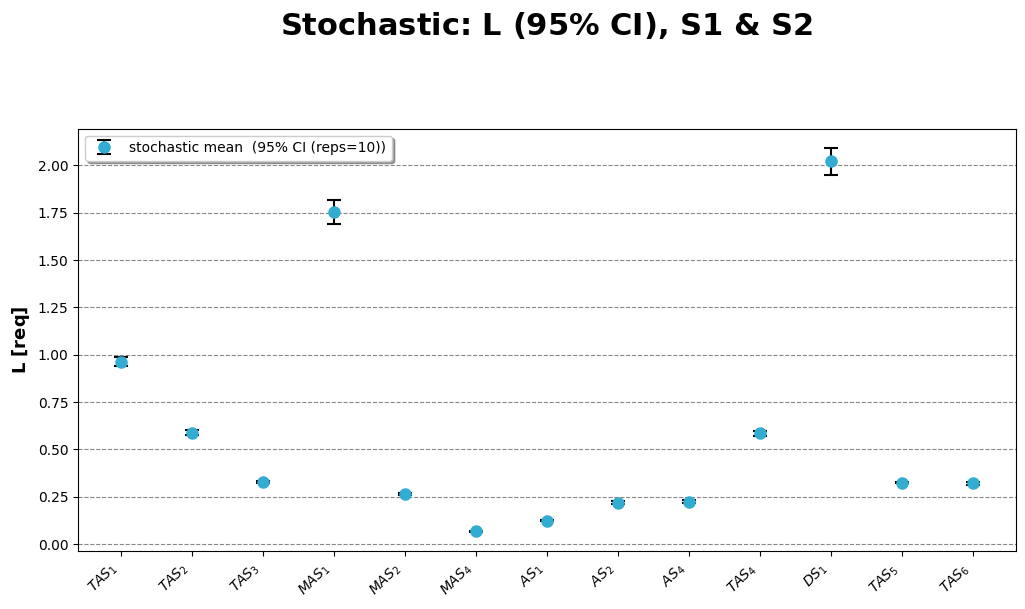

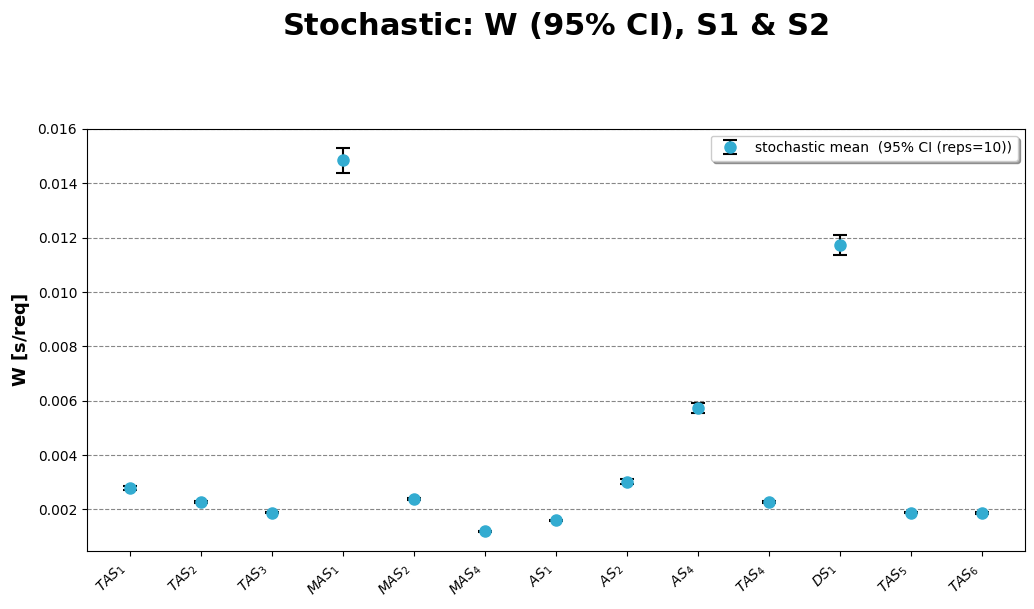

In [10]:
for a in ADAPTATIONS:
    plot_node_ci(
        nds=nodes[a],
        metric="rho",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{\rho}$",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{\\rho}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_rho.png")
    plot_node_ci(
        nds=nodes[a],
        metric="L",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{L}$ [req]",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{L}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_L.png")
    plot_node_ci(
        nds=nodes[a],
        metric="W",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{W}$ [s/req]",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{W}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_W.png")

## 7. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive R1 / R2. Log y-axis because metrics span several orders of magnitude.

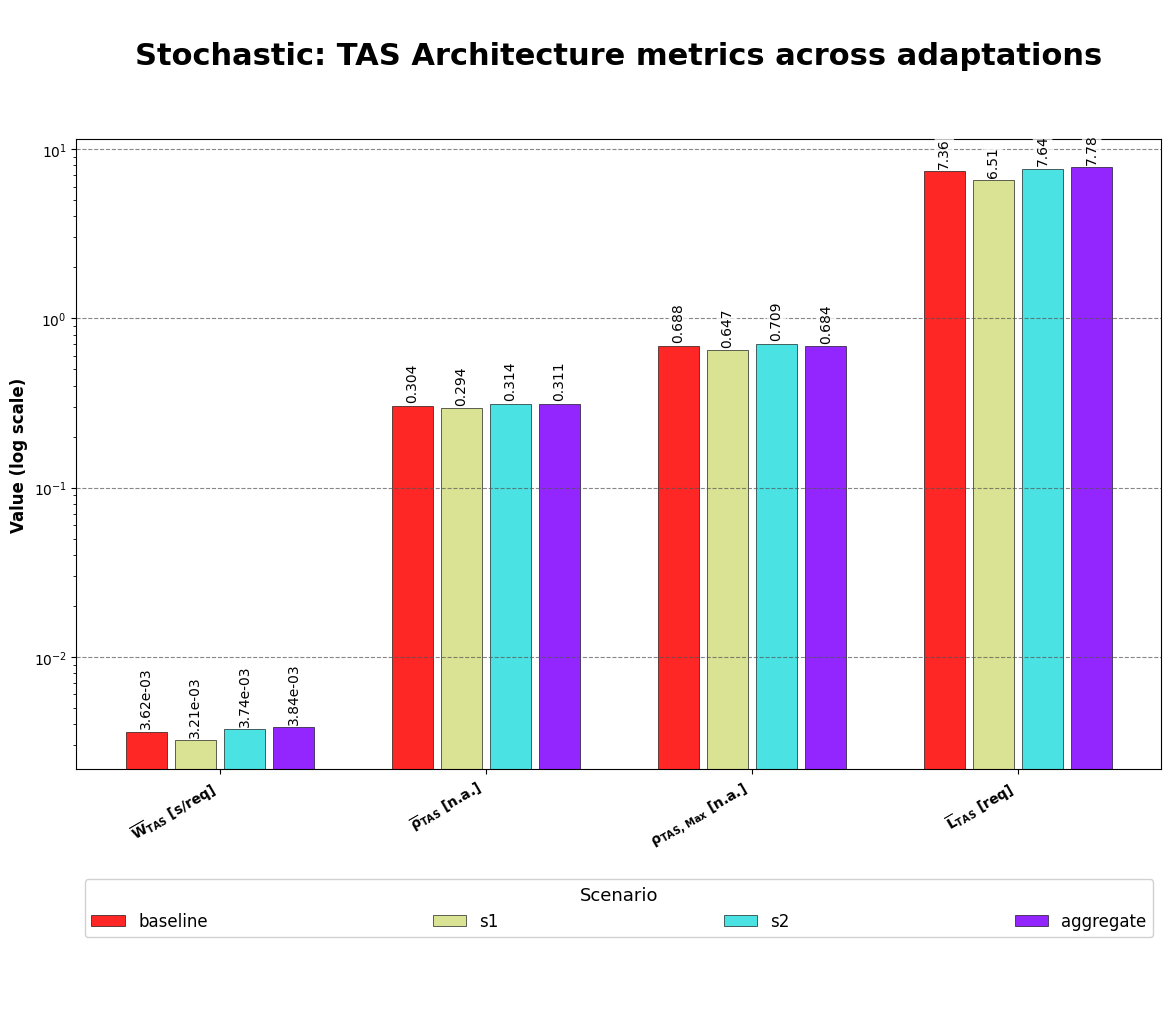

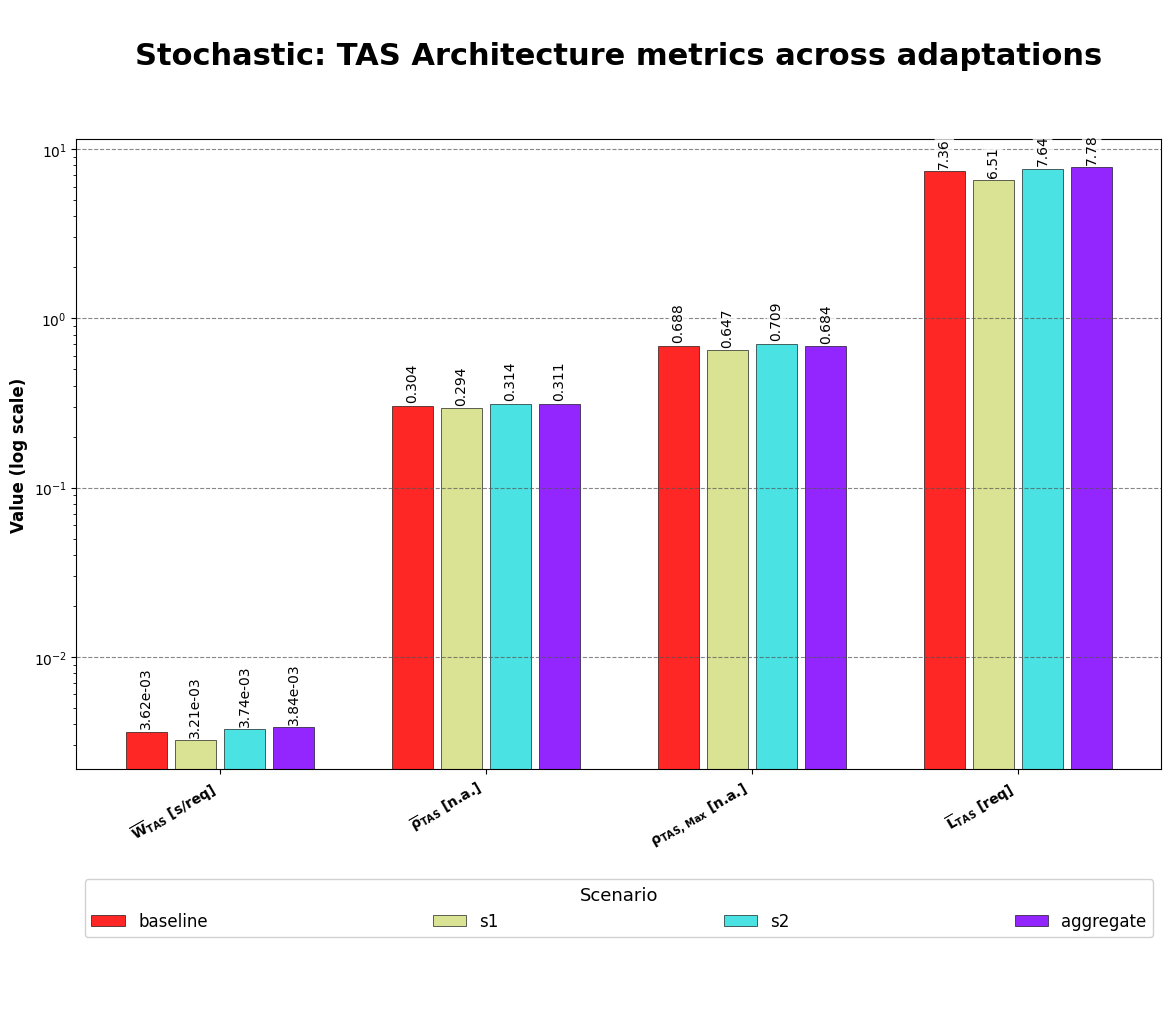

In [11]:
bar_metrics = ["W_net", "avg_rho", "max_rho", "L_net"]
bar_labels = [
    r"$\mathbf{\overline{W}_{TAS}}$ [s/req]",
    r"$\mathbf{\overline{\rho}_{TAS}}$ [n.a.]",
    r"$\mathbf{\rho_{TAS,\,Max}}$ [n.a.]",
    r"$\mathbf{\overline{L}_{TAS}}$ [req]",
]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    title="Stochastic: TAS Architecture metrics across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 8. Network-wide delta (% change vs baseline)

Semantic colouring: negative delta = improvement (green), positive = degradation (red).

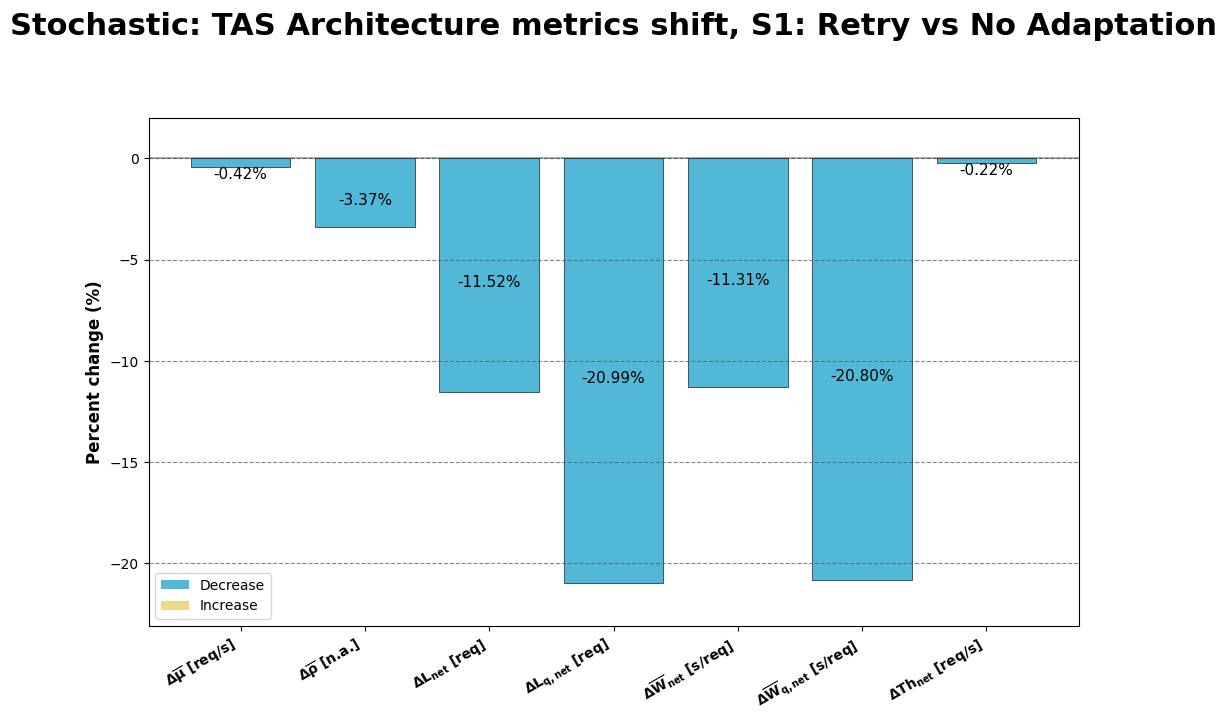

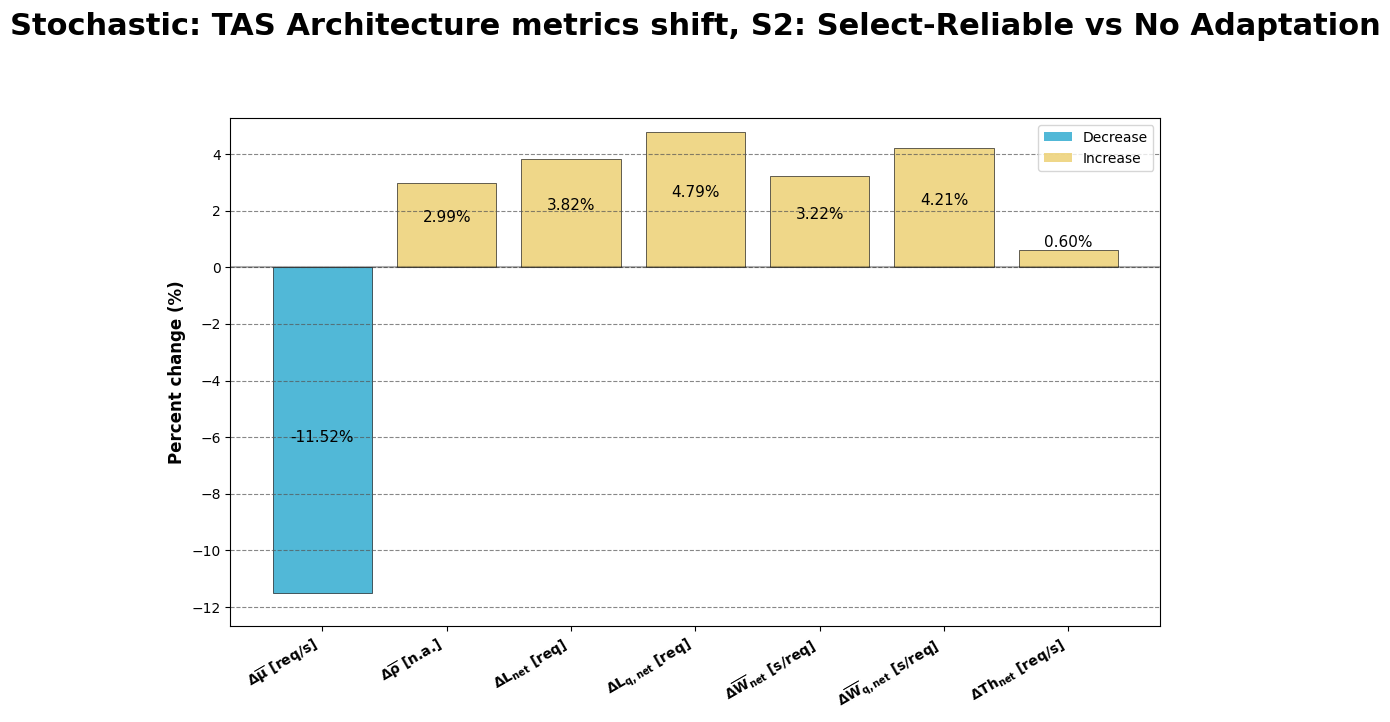

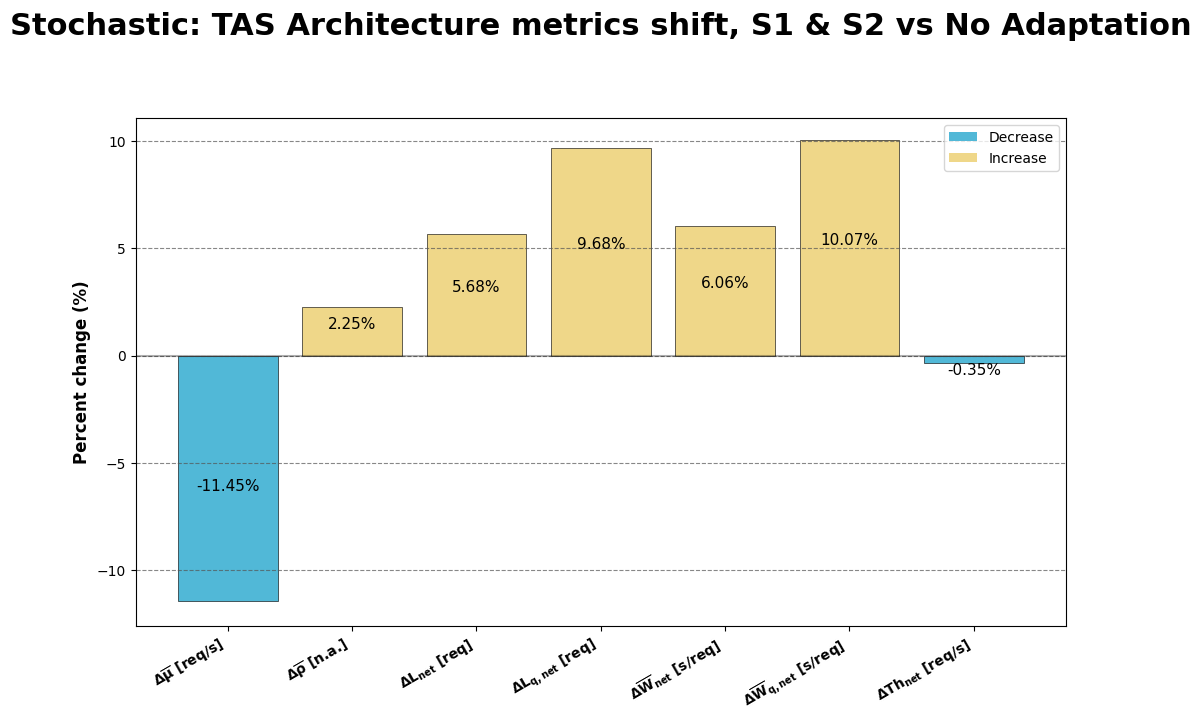

In [12]:
delta_metrics = [
    "avg_mu", "avg_rho",
    "L_net", "Lq_net",
    "W_net", "Wq_net",
    "total_throughput",
]
delta_labels = [
    r"$\mathbf{\Delta \overline{\mu}}$ [req/s]",
    r"$\mathbf{\Delta \overline{\rho}}$ [n.a.]",
    r"$\mathbf{\Delta L_{net}}$ [req]",
    r"$\mathbf{\Delta L_{q,net}}$ [req]",
    r"$\mathbf{\Delta \overline{W}_{net}}$ [s/req]",
    r"$\mathbf{\Delta \overline{W}_{q,net}}$ [s/req]",
    r"$\mathbf{\Delta Th_{net}}$ [req/s]",
]
bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in delta_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=delta_metrics,
        labels=delta_labels,
        title=f"Stochastic: TAS Architecture metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")

## 9. R1 / R2 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):
- **R1** Availability: `fail_rate <= 0.03 %`
- **R2** Performance: `resp_time <= 26 ms`

In [13]:
req_rows = []
for a in ADAPTATIONS:
    r = reqs[a]
    req_rows.append({
        "adaptation": a,
        "R1 fail_rate": r["R1"]["value"],
        "R1 pass": r["R1"]["pass"],
        "R2 resp_time (s)": r["R2"]["value"],
        "R2 pass": r["R2"]["pass"],
    })
pd.DataFrame(req_rows).set_index("adaptation")

,R1 fail_rate,R1 pass,R2 resp_time (s),R2 pass
adaptation,,,,
baseline,0.0,True,0.003622,True
s1,0.0,True,0.003213,True
s2,0.0,True,0.003739,True
aggregate,0.0,True,0.003842,True


## Summary

At the nominal 345 req/s arrival rate, the SimPy DES produces per-node W, L, rho / CI bands that the analytic closed-form solution falls inside, validating both methods.

**Next method in the pipeline**: `dimensional.ipynb` (PyDASA pi-groups + Monte-Carlo sensitivity).